# Abstention & structure sociale — croisement INSEE × élections municipales

On joint enfin les **résultats électoraux** à la table communale INSEE, par `CODGEO`, appariés par
cycle : **municipales 2014 ↔ RP 2013** et **2020 ↔ 2019** (couverture complète). Le cycle
**2008 ↔ 2007** existe mais n'est fourni que pour les communes ≥ 3 500 hab. (résultats détaillés
non publiés pour les petites communes à l'époque) — on le traite à part.

On peut désormais **mesurer** l'abstention et tester les hypothèses formulées jusqu'ici.

In [1]:
import os, sys
import numpy as np, pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
sys.path.append(os.path.abspath('../..'))
import src.eda_utils as eu
from src.features_insee import charger_tables, construire_features
from src.resultats_loader import charger_abstention

sns.set_theme(style="whitegrid", context="talk")
plt.rcParams.update({"axes.titlesize": 16, "axes.labelsize": 13, "legend.fontsize": 12})
CMAP_SEQ, CMAP_CORR = "mako", "vlag"
PAL_ANNEES = sns.color_palette("deep")[:2]
PAL_STRATE = sns.color_palette("crest", 4)

RES = "../../data/raw/Resultat/"
# Table socio-économique (nettoyée + strates) par millésime
insee = {an: eu.stratifier(eu.nettoyer(construire_features(charger_tables(an), an))) for an in (2013, 2019)}
# Abstention communale (1er tour)
abst = {2014: charger_abstention(2014, RES + "2014_Bvot_T1T2.txt"),
        2020: charger_abstention(2020, RES + "2020-05-18-resultats-par-niveau-burvot-t1-france-entiere.xlsx")}

# Panels appariés
P = {2014: insee[2013].merge(abst[2014], on="CODGEO"),
     2020: insee[2019].merge(abst[2020], on="CODGEO")}
for an, p in P.items():
    print(f"Municipales {an} : {len(p):,} communes appariées | abstention moyenne {p['taux_abstention'].mean()*100:.1f} %")

Municipales 2014 : 36,462 communes appariées | abstention moyenne 25.6 %
Municipales 2020 : 34,715 communes appariées | abstention moyenne 40.9 %


## 1. Niveau et évolution de l'abstention

*L'abstention aux municipales a bondi entre 2014 et 2020 (contexte Covid). Se répartit-elle de la
même façon sur le territoire ?*

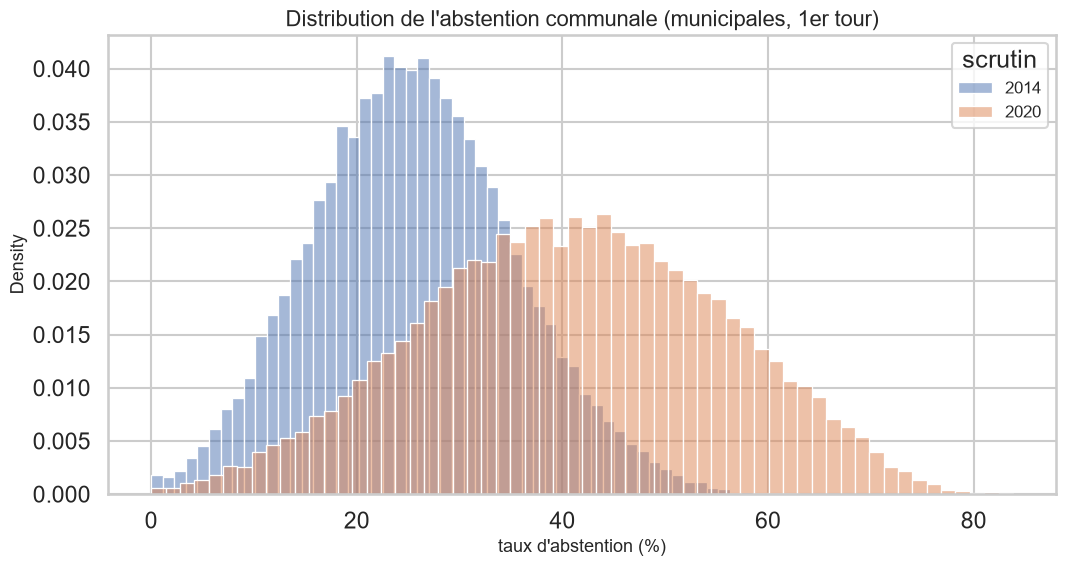

In [2]:
fig, ax = plt.subplots(figsize=(11, 6))
for (an, p), col in zip(P.items(), PAL_ANNEES):
    sns.histplot(p["taux_abstention"] * 100, bins=60, stat="density", color=col, alpha=.5, label=f"{an}", ax=ax)
ax.set_title("Distribution de l'abstention communale (municipales, 1er tour)")
ax.set_xlabel("taux d'abstention (%)"); ax.legend(title="scrutin")
plt.tight_layout(); plt.show()

**Lecture.** La distribution 2020 est nettement décalée vers la droite (Covid) : ~26 % → ~41 % en
moyenne. Mais la *forme* est proche — la hiérarchie territoriale se déplace en bloc, ce qui suggère
un déterminant structurel stable.

## 2. Abstention selon le type de territoire

C:\Users\HP\AppData\Local\Temp\ipykernel_22568\1605669868.py:6: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator. Otherwise, ticks may be mislabeled.
  ax.set_xticklabels([l.split()[0] for l in eu.STRATE_LABELS], rotation=0)
C:\Users\HP\AppData\Local\Temp\ipykernel_22568\1605669868.py:6: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator. Otherwise, ticks may be mislabeled.
  ax.set_xticklabels([l.split()[0] for l in eu.STRATE_LABELS], rotation=0)


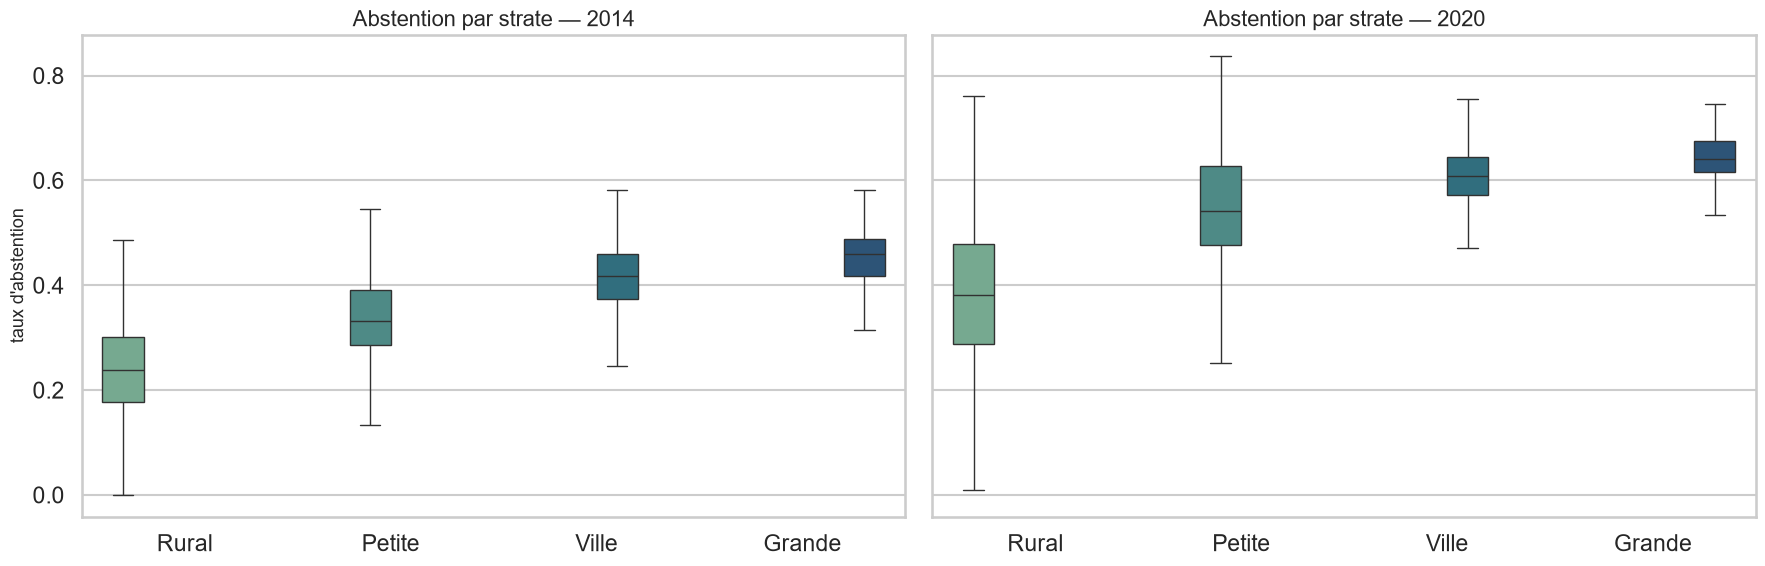

In [3]:
fig, axes = plt.subplots(1, 2, figsize=(18, 6), sharey=True)
for ax, an in zip(axes, (2014, 2020)):
    sns.boxplot(data=P[an], x="strate", y="taux_abstention", hue="strate",
                palette=PAL_STRATE, legend=False, showfliers=False, ax=ax)
    ax.set_title(f"Abstention par strate — {an}"); ax.set_xlabel("")
    ax.set_xticklabels([l.split()[0] for l in eu.STRATE_LABELS], rotation=0)
    ax.set_ylabel("taux d'abstention")
plt.tight_layout(); plt.show()

**Interprétation.** L'abstention **croît avec la taille de la commune**, aux deux scrutins : on vote
davantage dans les petites communes rurales. Cohérent avec la sociologie de la participation locale :
proximité, interconnaissance, enjeu municipal plus tangible dans les petites communes.

## 3. Quels facteurs sociaux corrèlent avec l'abstention ?

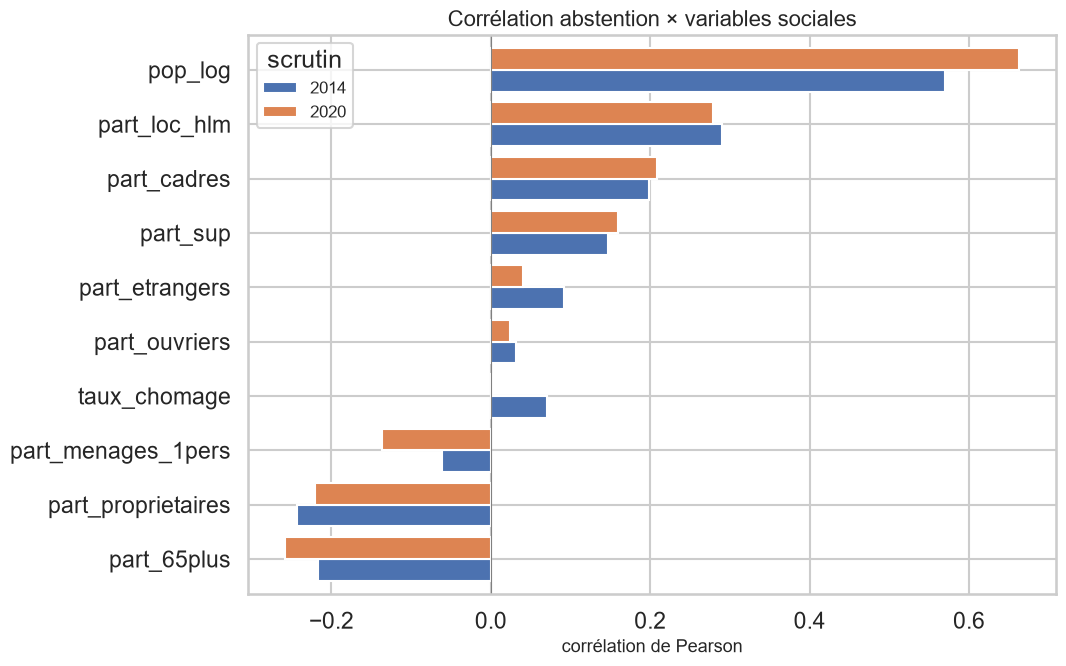

,2014,2020
pop_log,0.570,0.663
taux_chomage,0.070,0.001
part_sup,0.147,0.160
part_cadres,0.198,0.209
part_ouvriers,0.032,0.024
part_65plus,-0.217,-0.258
part_proprietaires,-0.243,-0.220
part_loc_hlm,0.290,0.279
part_etrangers,0.092,0.040
part_menages_1pers,-0.061,-0.136


In [4]:
vars_ = ["pop_log","taux_chomage","part_sup","part_cadres","part_ouvriers","part_65plus",
         "part_proprietaires","part_loc_hlm","part_etrangers","part_menages_1pers"]
corr = pd.DataFrame({an: P[an][vars_].corrwith(P[an]["taux_abstention"]) for an in (2014, 2020)})

fig, ax = plt.subplots(figsize=(11, 7))
corr.sort_values(2020).plot.barh(ax=ax, color=PAL_ANNEES, width=.8)
ax.axvline(0, color="grey", lw=.8); ax.set_title("Corrélation abstention × variables sociales")
ax.set_xlabel("corrélation de Pearson"); ax.legend(title="scrutin")
plt.tight_layout(); plt.show()
display(corr.round(3))

**Lecture (corrélations simples).** Aux deux scrutins : `pop_log` (taille) est de loin le plus lié
(+0,57 en 2014, +0,66 en 2020) ; `part_65plus` et `part_proprietaires` sont **négatifs** (l'âge et la
propriété font participer) ; `part_loc_hlm` et `part_cadres` **positifs**. Structure remarquablement
**stable** d'un scrutin à l'autre.

## 4. Le facteur dominant : la taille de commune (urbain/rural)

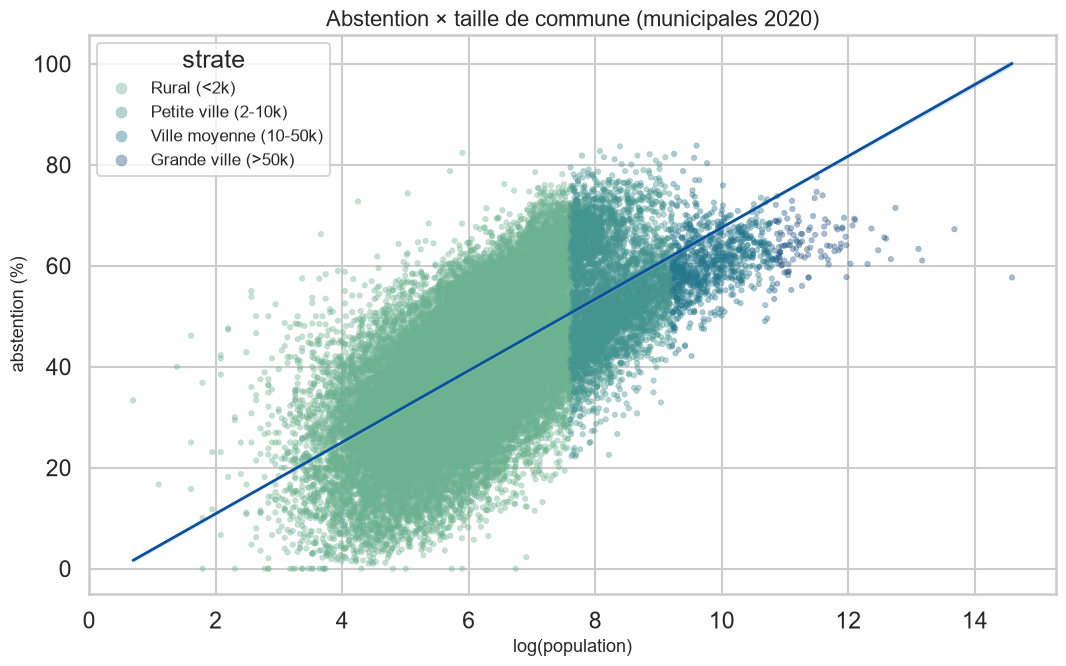

In [5]:
fig, ax = plt.subplots(figsize=(11, 7))
p = P[2020]
sns.scatterplot(data=p, x="pop_log", y=p["taux_abstention"]*100, hue="strate",
                palette=PAL_STRATE, s=16, alpha=.4, edgecolor=None, ax=ax)
sns.regplot(data=p, x="pop_log", y=p["taux_abstention"]*100, scatter=False,
            color="#08519c", line_kws={"lw": 2}, ax=ax)
ax.set_title("Abstention × taille de commune (municipales 2020)")
ax.set_xlabel("log(population)"); ax.set_ylabel("abstention (%)"); ax.legend(title="strate", markerscale=2)
plt.tight_layout(); plt.show()

## 5. Effets *nets* : que reste-t-il quand on contrôle la taille ?

*Question cruciale de méthode : les liens « cadres » ou « HLM » sont-ils réels, ou juste le reflet du
fait que ces groupes vivent en ville ? On l'isole par une régression standardisée.*

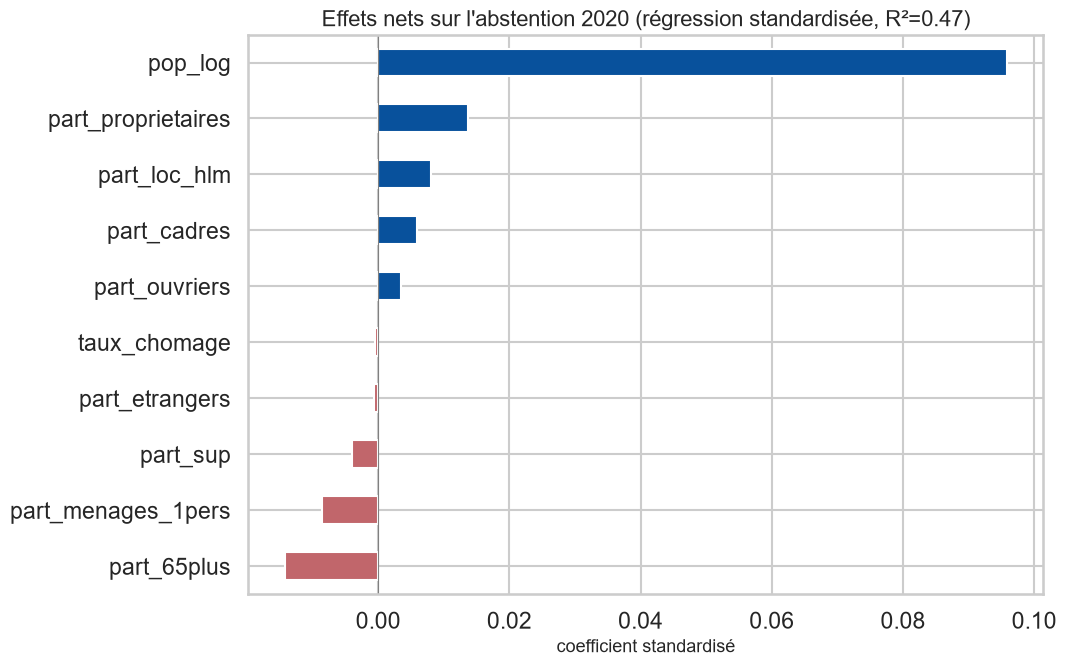

In [6]:
from sklearn.linear_model import LinearRegression
from sklearn.preprocessing import StandardScaler

p = P[2020]
X = StandardScaler().fit_transform(p[vars_]); y = p["taux_abstention"].values
reg = LinearRegression().fit(X, y)
coef = pd.Series(reg.coef_, index=vars_).sort_values()

fig, ax = plt.subplots(figsize=(11, 7))
coef.plot.barh(ax=ax, color=[("#08519c" if v > 0 else "#c1666b") for v in coef])
ax.axvline(0, color="grey", lw=.8)
ax.set_title(f"Effets nets sur l'abstention 2020 (régression standardisée, R²={reg.score(X,y):.2f})")
ax.set_xlabel("coefficient standardisé")
plt.tight_layout(); plt.show()

**Résultat central.** Une fois la **taille de commune contrôlée**, presque tous les effets
socio-économiques **s'effondrent** : `pop_log` reste massif, les autres deviennent marginaux. Les
corrélations « cadres » (+0,21) ou « HLM » (+0,28) vues en §3 étaient donc **en grande partie un effet
de taille masqué** — ces groupes se concentrent en ville, et c'est la ville (la taille) qui commande
l'abstention, pas la composition sociale en elle-même.

**Piège de l'inférence écologique.** Ces relations sont mesurées *au niveau commune* : elles ne
disent pas qu'un cadre s'abstient plus qu'un ouvrier (au contraire, à l'échelle individuelle, c'est
souvent l'inverse). Le clivage territorial urbain/rural est ici le **maître-variable**.

## 6. Synthèse & prochaine étape

- L'abstention municipale est d'abord une affaire de **taille de commune / urbanité** : forte en
  ville, faible dans le rural — et ce, aux deux scrutins (structure stable, niveau qui monte).
- L'**âge** et la **propriété** favorisent la participation ; le **logement social** l'abaisse — mais
  ces effets sont largement **médiés par la taille**.
- Le vrai déterminant est donc **territorial** plus que strictement social, à l'échelle communale.

**Suite** : (1) intégrer le **revenu** (FiLoSoFi) et la **densité**, qui manquent et pourraient porter
un effet propre ; (2) passer à une **modélisation** (régression avec effets départementaux, ou modèle
non linéaire) pour hiérarchiser proprement les facteurs ; (3) analyser l'**orientation politique**
(via les nuances des listes, déjà présentes dans les fichiers de résultats), pas seulement la
participation.